# Task exploration — `fdgo` dynamics

Load a trained **DaleRNN** checkpoint and probe **fdgo** (fixation-delayed go):

1. **100 forward passes** — fresh stimulus batches each pass, noise-free evaluation
2. **PCA of hidden activity** — do neural trajectories *reach* stimulus-specific endpoints after the go cue?

**Reaching** here means: after the go signal, population activity moves through state space and settles near a target that depends on the stimulus location (a line or cluster of fixed points in PC space), rather than staying on a single shared trajectory.

In [10]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.decomposition import PCA

from network import popvec
from task import generate_trials
from train_cog import (
    batch_accuracy,
    decode_ring,
    load_checkpoint,
    ring_prefs,
    trial_to_tensors,
)

plt.style.use("dark_background")

CHECKPOINT_PATH = "checkpoints/dale_20_30000_2026-08-30_21-13-44.pt"
TASK = "fdgo"
N_PASSES = 320
BATCH_SIZE = 64
N_PCS = 3

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, config, checkpoint = load_checkpoint(CHECKPOINT_PATH, device=device, eval_mode=True)
prefs = ring_prefs(config, device, torch.float32)
dt = config["dt"]

print(f"device={device}")
print(f"model={checkpoint['model_type']}  n_units={model.n_rnn}  train_steps={checkpoint.get('train_steps')}")
print(f"tasks in checkpoint ({len(checkpoint['active_tasks'])}): {checkpoint['active_tasks'][:5]} ...")

DaleRNN: N=256  frac_e=0.8  rho(W)=1.000  activation=relu
Loaded checkpoint <- C:\Users\athar\Documents\Github\canonical_mc\checkpoints\dale_20_30000_2026-08-30_21-13-44.pt  model=dale  tasks=['fdgo', 'reactgo', 'delaygo', 'fdanti', 'reactanti', 'delayanti', 'dm1', 'dm2', 'contextdm1', 'contextdm2', 'multidm', 'delaydm1', 'delaydm2', 'contextdelaydm1', 'contextdelaydm2', 'multidelaydm', 'dmsgo', 'dmsnogo', 'dmcgo', 'dmcnogo']
device=cpu
model=dale  n_units=256  train_steps=30000
tasks in checkpoint (20): ['fdgo', 'reactgo', 'delaygo', 'fdanti', 'reactanti'] ...


## `fdgo` — task recap

**Rule:** Stimulus appears on the input ring during fixation; when fixation drops (go cue), saccade to the **same** stimulus location.

**Phases:** `fix1` → `stim1` → `go1`

Nearly feedforward: no delay, no anti-response, no decision. A well-trained network should hold fixation pre-go, then shift its readout bump to the stimulus angle.

In [12]:
def target_angle_from_trial(trial):
    """Stimulus / saccade target angle (rad) for each trial in batch."""
    y_loc = trial.y_loc  # (T, B)
    go = y_loc >= 0
    locs = []
    for b in range(trial.batch_size):
        idx = np.where(go[:, b])[0]
        locs.append(y_loc[idx[0], b] if len(idx) else np.nan)
    return np.array(locs)


def run_fdgo_passes(model, config, n_passes, batch_size, device):
    """Run n_passes noise-free fdgo batches; return per-pass metrics and activity chunks."""
    model.eval()
    metrics = []
    activity_chunks = []

    with torch.no_grad():
        for p in range(n_passes):
            trial = generate_trials(TASK, config, batch_size, noise_on=False)
            x, y, c_mask, y_loc = trial_to_tensors(trial, device)
            h_hist, _, output = model.simulate(x, noise_level=0.0)

            acc = batch_accuracy(output, y_loc, prefs)
            loss = (c_mask * (output - y).square()).mean().item()
            metrics.append({"pass": p, "loss": loss, **acc})

            # post-fixation hidden rates: (T, B, N)
            t_start = trial.epochs["fix1"][1]
            h = h_hist[:, t_start:, :].permute(1, 0, 2).cpu().numpy()
            stim_ang = target_angle_from_trial(trial)
            activity_chunks.append({"h": h, "stim_ang": stim_ang, "trial": trial, "t_start": t_start})

            if p == 0 or (p + 1) % 25 == 0 or p == n_passes - 1:
                print(
                    f"pass {p + 1:3d}/{n_passes} | acc={acc['acc']:.3f} "
                    f"go={acc['go_acc']:.3f} fix={acc['fix_acc']:.3f} loss={loss:.4f}"
                )

    return metrics, activity_chunks


metrics, activity_chunks = run_fdgo_passes(
    model, config, N_PASSES, BATCH_SIZE, device
)
n_trials = N_PASSES * BATCH_SIZE
print(f"\n{n_trials} trials total ({N_PASSES} passes × {BATCH_SIZE} batch)")

pass   1/320 | acc=0.984 go=0.984 fix=1.000 loss=0.0005
pass  25/320 | acc=1.000 go=1.000 fix=1.000 loss=0.0005
pass  50/320 | acc=1.000 go=1.000 fix=1.000 loss=0.0005
pass  75/320 | acc=1.000 go=1.000 fix=1.000 loss=0.0005
pass 100/320 | acc=0.984 go=0.984 fix=1.000 loss=0.0005
pass 125/320 | acc=1.000 go=1.000 fix=1.000 loss=0.0005
pass 150/320 | acc=1.000 go=1.000 fix=1.000 loss=0.0005
pass 175/320 | acc=1.000 go=1.000 fix=1.000 loss=0.0005
pass 200/320 | acc=1.000 go=1.000 fix=1.000 loss=0.0005
pass 225/320 | acc=1.000 go=1.000 fix=1.000 loss=0.0005
pass 250/320 | acc=1.000 go=1.000 fix=1.000 loss=0.0005
pass 275/320 | acc=0.984 go=0.984 fix=1.000 loss=0.0005
pass 300/320 | acc=0.984 go=0.984 fix=1.000 loss=0.0004
pass 320/320 | acc=1.000 go=1.000 fix=1.000 loss=0.0005

20480 trials total (320 passes × 64 batch)


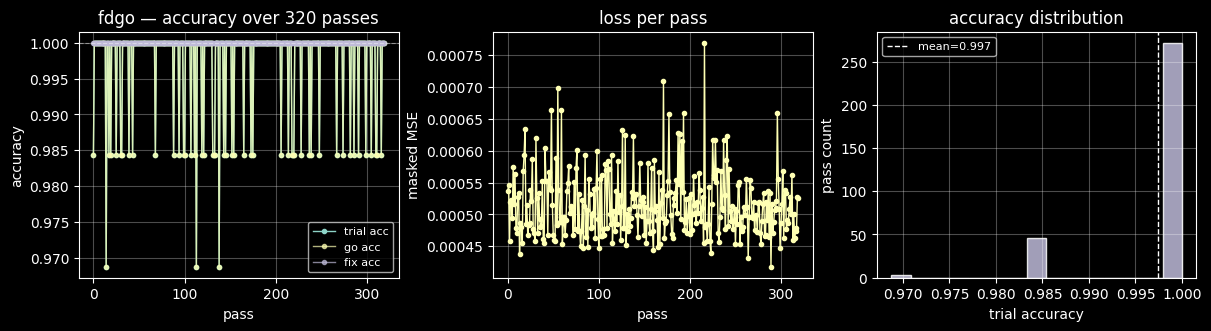

Summary: acc mean=0.997 ± 0.006 | go=0.997 | fix=1.000 | loss=0.0005


In [13]:
acc_all = np.array([m["acc"] for m in metrics])
go_all = np.array([m["go_acc"] for m in metrics])
fix_all = np.array([m["fix_acc"] for m in metrics])
loss_all = np.array([m["loss"] for m in metrics])

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), layout="constrained")
axes[0].plot(acc_all, "o-", ms=3, lw=1, label="trial acc")
axes[0].plot(go_all, "o-", ms=3, lw=1, alpha=0.7, label="go acc")
axes[0].plot(fix_all, "o-", ms=3, lw=1, alpha=0.7, label="fix acc")
axes[0].axhline(1.0, color="w", ls="--", lw=0.8, alpha=0.4)
axes[0].set_xlabel("pass")
axes[0].set_ylabel("accuracy")
axes[0].set_title(f"{TASK} — accuracy over {N_PASSES} passes")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(loss_all, "C1o-", ms=3, lw=1)
axes[1].set_xlabel("pass")
axes[1].set_ylabel("masked MSE")
axes[1].set_title("loss per pass")
axes[1].grid(True, alpha=0.3)

axes[2].hist(acc_all, bins=15, color="C2", alpha=0.85, edgecolor="white")
axes[2].axvline(acc_all.mean(), color="w", ls="--", lw=1,
                label=f"mean={acc_all.mean():.3f}")
axes[2].set_xlabel("trial accuracy")
axes[2].set_ylabel("pass count")
axes[2].set_title("accuracy distribution")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)
plt.show()

print(
    f"Summary: acc mean={acc_all.mean():.3f} ± {acc_all.std():.3f} | "
    f"go={go_all.mean():.3f} | fix={fix_all.mean():.3f} | loss={loss_all.mean():.4f}"
)

## PCA — do trajectories reach stimulus-specific states?

We pool hidden activity from all passes, fit PCA on the **go epoch** (when the network must produce the saccade), and plot trajectories in PC space.

**Signs of reaching:**
- Trajectories with different stimulus angles end at **separated** points in PC space
- Distance to the final state **decreases** over time after go onset (convergence)
- Endpoints form a **ring-like** structure matching stimulus locations

In [14]:
def pool_activity_for_pca(activity_chunks):
    """Stack trials; pad variable-length post-fixation segments to common T."""
    trial_h = []
    trial_ang = []
    go_onsets = []

    for chunk in activity_chunks:
        h = chunk["h"]  # (T, B, N) — T varies across passes
        trial = chunk["trial"]
        go_t = trial.epochs["go1"][0] - chunk["t_start"]
        go_t = max(0, go_t)
        for b in range(h.shape[1]):
            trial_h.append(h[:, b, :])
            trial_ang.append(chunk["stim_ang"][b])
            go_onsets.append(go_t)

    t_max = max(arr.shape[0] for arr in trial_h)
    padded = []
    for arr in trial_h:
        if arr.shape[0] < t_max:
            pad = t_max - arr.shape[0]
            arr = np.pad(arr, ((0, pad), (0, 0)), mode="edge")
        padded.append(arr)

    trial_h = np.stack(padded, axis=0)  # (n_trials, T, N)
    trial_ang = np.array(trial_ang)
    go_onsets = np.array(go_onsets)
    return trial_h, trial_ang, go_onsets


trial_h, trial_ang, go_onsets = pool_activity_for_pca(activity_chunks)
T, N = trial_h.shape[1], trial_h.shape[2]
print(f"trial_h shape: {trial_h.shape}  (trials × time × units)")
print(f"post-fix T range across passes: padded to T={T}")

# PCA fit on go-epoch activity (all trials, all go timesteps)
go_mask = np.zeros(T, dtype=bool)
go_start = int(np.median(go_onsets))
go_mask[go_start:] = True
X_go = trial_h[:, go_mask, :].reshape(-1, N)

pca = PCA(n_components=N_PCS)
pca.fit(X_go)
print(f"variance explained (PC1–PC{N_PCS}): {pca.explained_variance_ratio_[:N_PCS].round(3)}")

# Project full trajectories
traj_pc = np.zeros((trial_h.shape[0], T, N_PCS))
for t in range(T):
    traj_pc[:, t, :] = pca.transform(trial_h[:, t, :])

t_rel_ms = (np.arange(T) - go_start) * dt

trial_h shape: (20480, 99, 256)  (trials × time × units)
post-fix T range across passes: padded to T=99
variance explained (PC1–PC3): [0.248 0.217 0.162]


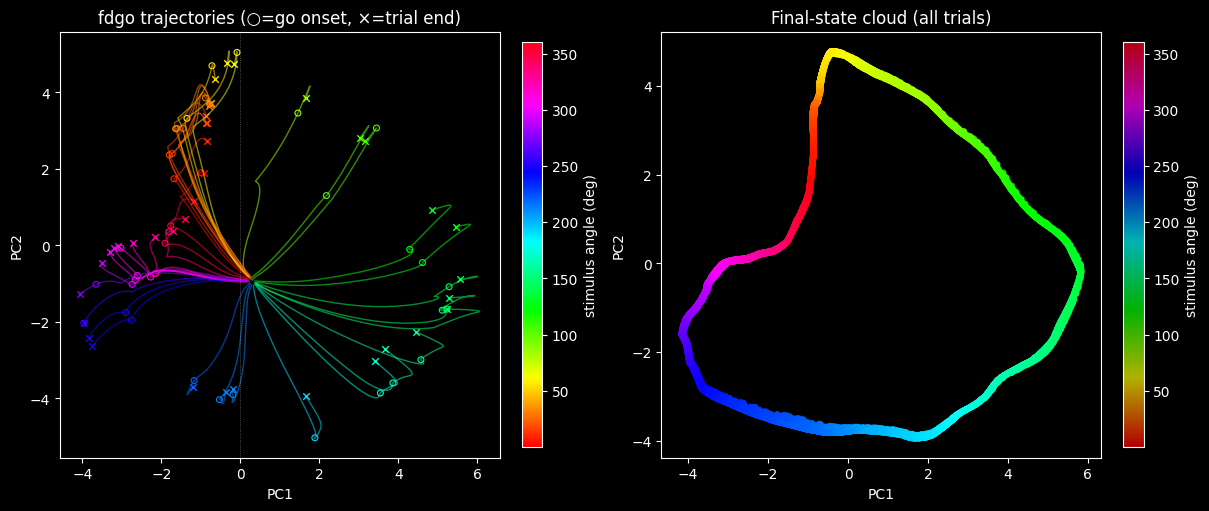

In [15]:
# --- PC trajectories colored by stimulus angle ---
n_show = min(40, trial_h.shape[0])
rng = np.random.default_rng(0)
show_idx = rng.choice(trial_h.shape[0], size=n_show, replace=False)
ang_deg = np.degrees(trial_ang)
norm = plt.Normalize(ang_deg.min(), ang_deg.max())
cmap = plt.cm.hsv

fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")

ax = axes[0]
for i in show_idx:
    c = cmap(norm(ang_deg[i]))
    ax.plot(traj_pc[i, :, 0], traj_pc[i, :, 1], color=c, alpha=0.55, lw=1)
    ax.scatter(traj_pc[i, go_start, 0], traj_pc[i, go_start, 1],
               s=18, facecolors="none", edgecolors=c, lw=0.8)
    ax.scatter(traj_pc[i, -1, 0], traj_pc[i, -1, 1], s=22, color=c, marker="x", lw=1)
ax.axvline(0, color="w", ls=":", lw=0.6, alpha=0.4)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"{TASK} trajectories (○=go onset, ×=trial end)")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=ax, label="stimulus angle (deg)", fraction=0.046)

# --- Endpoints in PC1–PC2, colored by angle ---
ax = axes[1]
sc = ax.scatter(traj_pc[:, -1, 0], traj_pc[:, -1, 1],
                c=ang_deg, cmap="hsv", s=12, alpha=0.7)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Final-state cloud (all trials)")
fig.colorbar(sc, ax=ax, label="stimulus angle (deg)", fraction=0.046)
plt.show()

In [ ]:
# --- Reaching metric: distance to own final state over time ---
final_pc = traj_pc[:, -1, :2]  # (trials, 2)
dist_to_final = np.linalg.norm(traj_pc[:, :, :2] - final_pc[:, None, :], axis=-1)
mean_dist = dist_to_final.mean(axis=0)
std_dist = dist_to_final.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), layout="constrained")

ax = axes[0]
for i in show_idx:
    ax.plot(t_rel_ms, dist_to_final[i], color=cmap(norm(ang_deg[i])), alpha=0.4, lw=0.8)
ax.axvline(0, color="w", ls="--", lw=1, label="go onset")
ax.plot(t_rel_ms, mean_dist, "w-", lw=2, label="mean across trials")
ax.fill_between(t_rel_ms, mean_dist - std_dist, mean_dist + std_dist,
                color="w", alpha=0.15)
ax.set_xlabel("time relative to go (ms)")
ax.set_ylabel("||PC(t) − PC(final)||")
ax.set_title("Convergence to final state (reaching)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Angular separation of final states vs stimulus separation
ax = axes[1]
pc_end = traj_pc[:, -1, :2]
from scipy.spatial.distance import pdist, squareform

pc_dists = squareform(pdist(pc_end))
# Circular angle distance (vectorized — pdist custom metric must return a scalar)
ang_diff = np.abs(
    np.arctan2(
        np.sin(trial_ang[:, None] - trial_ang[None, :]),
        np.cos(trial_ang[:, None] - trial_ang[None, :]),
    )
)
mask = np.triu(np.ones_like(pc_dists, dtype=bool), k=1)
ax.scatter(np.degrees(ang_diff[mask]), pc_dists[mask], s=8, alpha=0.35, c="C0")
ax.set_xlabel("stimulus angle separation (deg)")
ax.set_ylabel("final-state PC distance")
ax.set_title("Do different stimuli → different endpoints?")
ax.grid(True, alpha=0.3)
plt.show()

pre_go = dist_to_final[:, :go_start].mean() if go_start > 0 else np.nan
post_go = dist_to_final[:, go_start:].mean()
print(f"Mean dist-to-final: pre-go={pre_go:.3f}  post-go={post_go:.3f}")
print(
    "Reaching: post-go distance should drop below pre-go if trajectories converge "
    "to stimulus-specific attractors after the go cue."
)

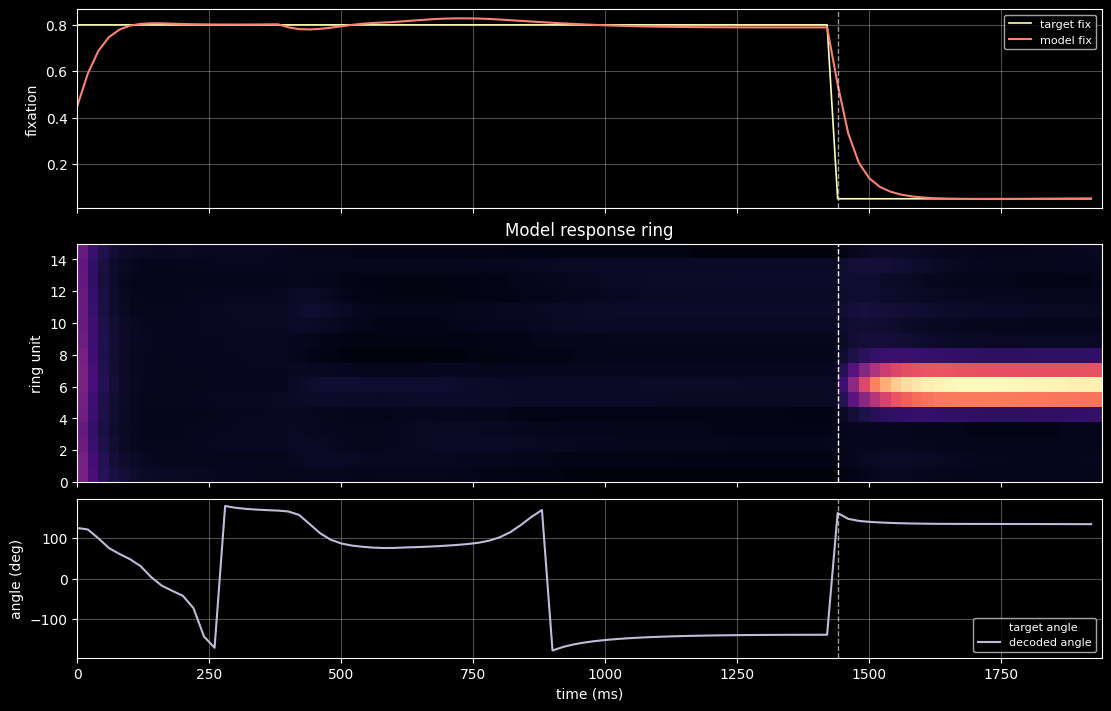

In [ ]:
# --- Example single-trial: model vs target (from first pass) ---
trial = activity_chunks[0]["trial"]
x, y, _, y_loc = trial_to_tensors(trial, device)
with torch.no_grad():
    _, _, output = model.simulate(x, noise_level=0.0)

b = 0
t_ms = np.arange(trial.tdim) * dt
y_np = y[b].cpu().numpy()
out_np = output[b].cpu().numpy()
go_ms = trial.epochs["go1"][0] * dt
pred_ang = decode_ring(output, prefs)[b].cpu().numpy()
tgt_ang = np.full(trial.tdim, np.nan)
go = y_loc[b].cpu().numpy() >= 0
tgt_ang[go] = y_loc[b].cpu().numpy()[go]

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True, layout="constrained",
                         height_ratios=[1, 1.2, 0.8])
axes[0].plot(t_ms, y_np[:, 0], "C1", lw=1.2, label="target fix")
axes[0].plot(t_ms, out_np[:, 0], "C3", lw=1.5, label="model fix")
axes[0].axvline(go_ms, color="w", ls="--", lw=1, alpha=0.6)
axes[0].set_ylabel("fixation")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

vmax = max(y_np[:, 1:].max(), out_np[:, 1:].max(), 0.1)
axes[1].imshow(out_np[:, 1:].T, aspect="auto", origin="lower", cmap="magma",
               extent=[0, t_ms[-1] + dt, 0, config["n_eachring"] - 1], vmin=0, vmax=vmax)
axes[1].axvline(go_ms, color="w", ls="--", lw=1)
axes[1].set_ylabel("ring unit")
axes[1].set_title("Model response ring")

axes[2].plot(t_ms, np.degrees(tgt_ang), "k--", lw=1.5, label="target angle")
axes[2].plot(t_ms, np.degrees(pred_ang), "C2", lw=1.5, label="decoded angle")
axes[2].axvline(go_ms, color="w", ls="--", lw=1, alpha=0.6)
axes[2].set_xlabel("time (ms)")
axes[2].set_ylabel("angle (deg)")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)
plt.show()